# **Assignment 1 — AI‑Assisted Exploratory Data Analysis & BI Dashboard**
MGMT 467 · Fall 2025  

**Team Name:** 10  
**Members (GitHub handles):** Ethan Quinn, Tomas Turner, Jack Strabala  
**GitHub Repo URL:** https://github.com/Tomas-Turner/Unit1_TheLook_Team10  
**Looker Studio Dashboard (public link):** https://lookerstudio.google.com/s/phSakL0hyRg

> **Scenario:** NYC DOT has asked your team to analyze the public Citi Bike program and recommend strategies to improve bike availability and engagement. You will use BigQuery + Gemini to conduct AI‑assisted EDA and publish an executive dashboard.

## ✅ Submission Checklist (Team → Brightspace)
- [ ] GitHub repository link (source of record)
- [ ] Looker Studio dashboard link
- [ ] This notebook committed to GitHub with prompts and results

### ✅ Submission Checklist (Individual → Brightspace)
- [ ] `Contribution_Reflection.pdf` (with commit/PR evidence + peer eval)

## 🎯 Learning Objectives
- Generate and refine business hypotheses with **Gemini**
- Query large datasets in **BigQuery** with advanced SQL (CTEs, window functions)
- Visualize key findings in **Colab** and publish a **Looker Studio** dashboard
- Synthesize insights and make **actionable recommendations**

## 🧰 Setup
> Run the cells below to connect Colab to Google Cloud & BigQuery.

In [5]:
# Install and import basics (Colab usually has these preinstalled)
# !pip install --quiet google-cloud-bigquery pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

# Authenticate to Google from Colab
from google.colab import auth  # type: ignore
auth.authenticate_user()

# Set your GCP project ID
PROJECT_ID = "mgmt-467-471819"  # <-- edit this
print("Using project:", PROJECT_ID)

Using project: mgmt-467-471819


In [6]:
# BigQuery magics (%%bigquery) and client
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

# Optional: list datasets to verify access
list(client.list_datasets())

## 🧪 Dataset
We will use **Citi Bike Trips**: `bigquery-public-data.new_york_citibike.citibike_trips`  
Feel free to explore additional public datasets if needed.

## 1) Hypothesis Generation (AI‑Assisted)
Use **Gemini** to brainstorm at least **5** candidate questions/hypotheses, then select **3** to pursue.

> **Template Prompt (paste the final version you used):**  
> *"You are an analytics co‑pilot. Propose 5 high‑value, testable business questions about the Citi Bike dataset (tripduration, stations, user types, time-of-day/week). Return as bullets with suggested SQL hints."*

Prompt: You are a data analytics assistant. Generate five meaningful and testable business questions using the New York Citi Bike dataset, each accompanied by a suggested SQL approach.

**Selected Hypotheses**
1. How does trip duration vary by user type (subscriber vs. customer)? SQL Approach: Group the data by usertype and calculate the average of the tripduration for each group.
2. What are the top 3 busiest start stations by the total number of trips? SQL Approach: Group the data by start_station_name, count the number of trips for each station, order the results in descending order of the trip count, and limit to the top 3.
3. How does the number of trips vary by the hour of the day and day of the week? SQL Approach: Extract the hour and day of the week from the starttime column. Group by the hour and day of the week and count the number of trips for each combination.

Here are 5 high-value business questions about Citi Bike trips:

*   **Question 1: How does trip duration vary by user type (subscriber vs. customer)?**
    *   *SQL Hint:* Group by `usertype` and calculate the average trip duration.
*   **Question 2: What are the busiest start and end stations, and how does this change by time of day or day of the week?**
    *   *SQL Hint:* Group by `start_station_name` and `end_station_name`, potentially adding a time-based grouping (e.g., hour of day, day of week) extracted from `starttime` or `stoptime`. Use `COUNT(*)` to find trip counts.
*   **Question 3: Are there specific routes (start station to end station) that are more popular than others, and how does this popularity correlate with trip duration?**
    *   *SQL Hint:* Concatenate or group by `start_station_name` and `end_station_name`. Calculate the average `tripduration` for each route and the total number of trips.
*   **Question 4: How does bike availability change throughout the day at key stations?**
    *   *SQL Hint:* This question might require analyzing the start and end times of trips at specific stations over time to infer bike movements. This could involve looking at the number of bikes leaving and arriving at stations within certain time windows.
*   **Question 5: What is the impact of the day of the week and time of day on the number of trips and average trip duration?**
    *   *SQL Hint:* Extract the day of the week and hour of the day from `starttime`. Group by these extracted fields and calculate the count of trips and the average `tripduration`.

## 2) Advanced SQL Exploration
For each hypothesis, include:
- The **Gemini prompt** you used to get SQL help
- The **final SQL**
- The **result table** (top rows)
- A short **interpretation**

> Tip: Use **CTEs** and at least **one window function** across your work.

### Hypothesis A — Prompt Log

Prompt: Provide the code needed to address my first hypothesis from the “Selected Hypothesis” section. It should follow the same format used for Hypothesis A, but specifically apply to the first hypothesis.

In [9]:
# Hypothesis A — SQL (store results in a Pandas DataFrame)
query_hyp_a = r"""
SELECT
    usertype,
    AVG(tripduration) AS average_trip_duration
FROM
    `bigquery-public-data.new_york_citibike.citibike_trips`
WHERE usertype IS NOT NULL AND tripduration IS NOT NULL
GROUP BY
    usertype
"""

df_hyp_a = client.query(query_hyp_a).to_dataframe()
df_hyp_a.head()

,usertype,average_trip_duration
0,Subscriber,806.381888
1,Customer,2145.512075


**Interpretation (2–4 sentences):** This query finds the average trip duration, in seconds. There is big discrepancy between subscribers and one-time customers, where subscribers only bike for 800 seconds on average, probably due to they feel it is worth it to ride for shorter distances, while non-subscribers only use the citibike for longer distances where they feel they are getting their money's worth.

---

### Hypothesis B — Prompt Log

Follow the same instructions as the previous hypothesis and ensure that null values are filtered out for hypothesis 2.

In [11]:
# Hypothesis B — SQL
query_hyp_b = r"""
SELECT
    start_station_name,
    COUNT(*) AS total_trips
FROM
    `bigquery-public-data.new_york_citibike.citibike_trips`
WHERE start_station_name IS NOT NULL AND start_station_name != ''
GROUP BY
    start_station_name
ORDER BY
    total_trips DESC
LIMIT 3
"""
df_hyp_b = client.query(query_hyp_b).to_dataframe()
df_hyp_b.head()

,start_station_name,total_trips
0,Pershing Square North,438077
1,E 17 St & Broadway,423334
2,W 21 St & 6 Ave,403795


**Interpretation (2–4 sentences):** This query found the top 3 highest starting stations by total number of trips. This data does not show the whole picture, since the majority of trips do not have a start station listed. But from this data collected, there seems to be higher demand for these three stations, so there should be more bikes stationed here to accompany the loads.

---

### Hypothesis C — Prompt Log

Now make the sql code for hypothesis 3, still ensuring to filter out null values.

In [15]:
# Hypothesis C — SQL
query_hyp_c = r"""
SELECT
    EXTRACT(HOUR FROM starttime) AS hour_of_day,
    EXTRACT(DAYOFWEEK FROM starttime) AS day_of_week,
    COUNT(*) AS total_trips
FROM
    `bigquery-public-data.new_york_citibike.citibike_trips`
WHERE starttime IS NOT NULL
GROUP BY
    hour_of_day,
    day_of_week
ORDER BY
    day_of_week,
    hour_of_day
"""
df_hyp_c = client.query(query_hyp_c).to_dataframe()
df_hyp_c

,hour_of_day,day_of_week,total_trips
0,0,1,100380
1,1,1,69999
2,2,1,45044
3,3,1,28785
4,4,1,18409
...,...,...,...
163,19,7,356539
164,20,7,252773
165,21,7,189914
166,22,7,162303


**Interpretation (2–4 sentences):** This shows the trips for each hour of the day, across the days of the week. Week days are busier, especially during travel hours, as many people use citibike to go to and from work.

## 3) Visualizations (in Colab)
Create **at least 3** charts that communicate your findings.  
> Keep charts readable and labeled. Use `matplotlib` (no specific styles required).

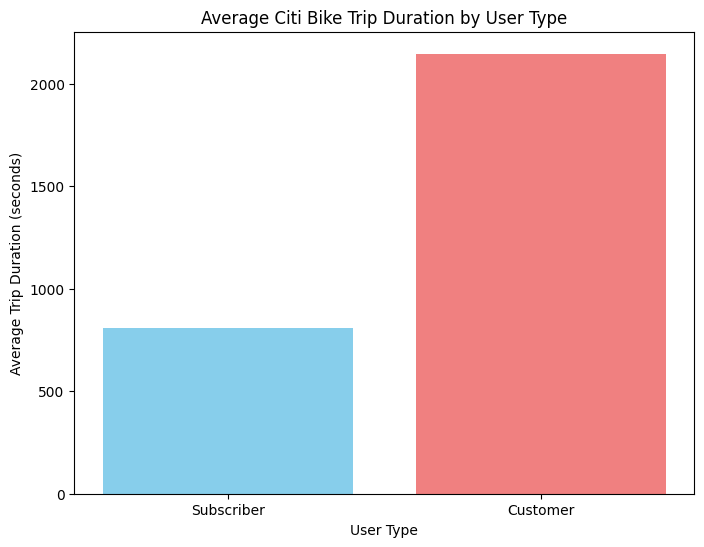

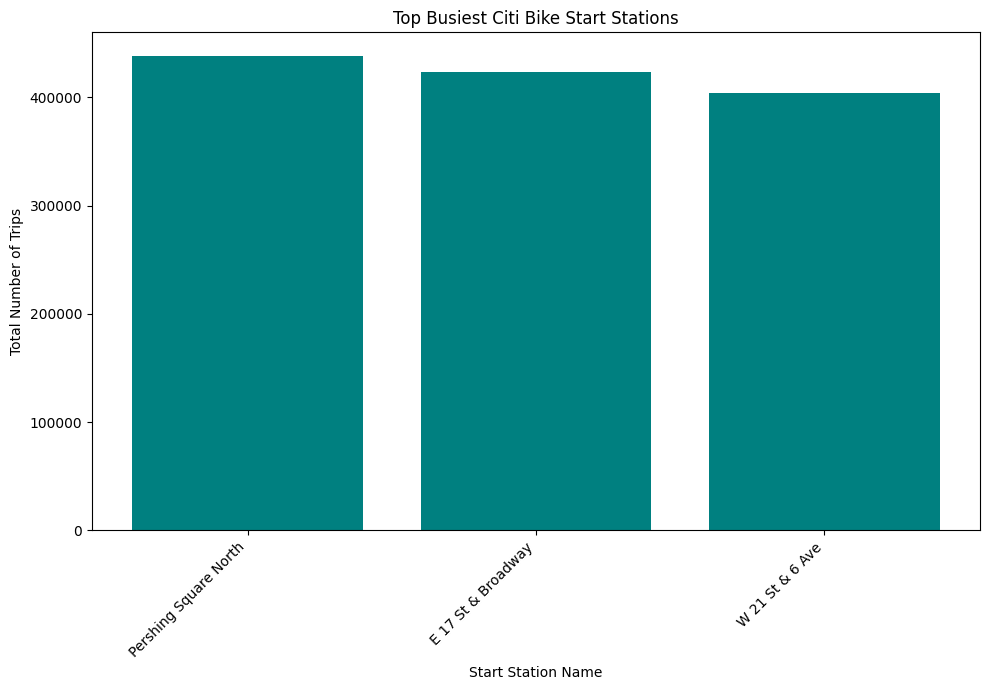

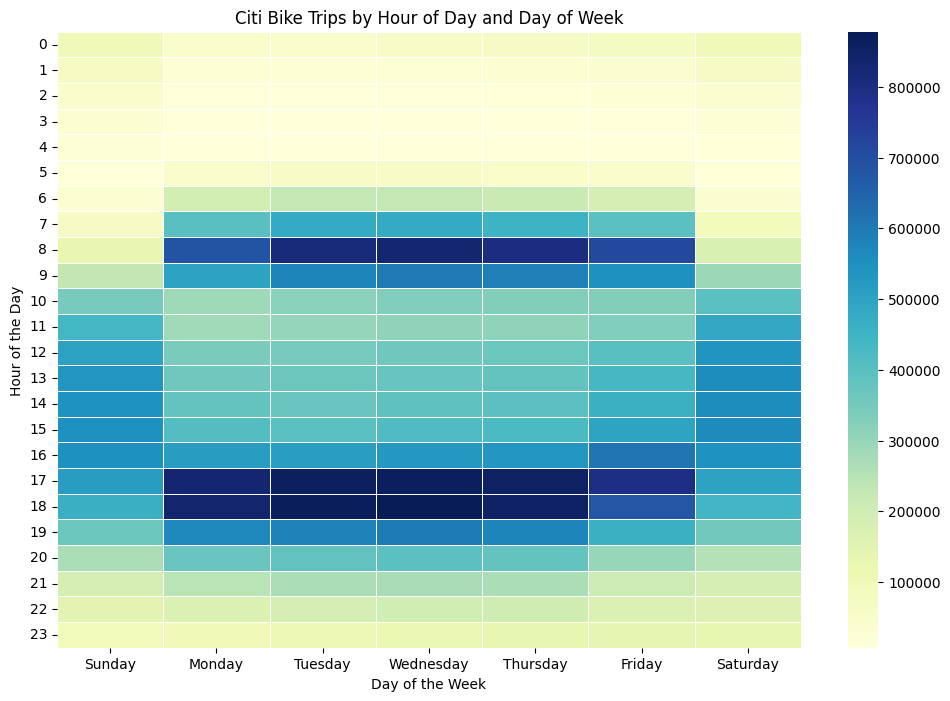

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # Seaborn is good for heatmaps

plt.figure(figsize=(8, 6)) # Adjust figure size as needed
plt.bar(df_hyp_a['usertype'], df_hyp_a['average_trip_duration'], color=['skyblue', 'lightcoral'])
plt.xlabel('User Type')
plt.ylabel('Average Trip Duration (seconds)')
plt.title('Average Citi Bike Trip Duration by User Type')
plt.show()

plt.figure(figsize=(10, 7)) # Adjust figure size for station names
plt.bar(df_hyp_b['start_station_name'], df_hyp_b['total_trips'], color='teal')
plt.xlabel('Start Station Name')
plt.ylabel('Total Number of Trips')
plt.title('Top Busiest Citi Bike Start Stations')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Convert 'total_trips' to integer type to ensure compatibility with heatmap
df_hyp_c['total_trips'] = df_hyp_c['total_trips'].astype(int)

# Pivot the data for the heatmap
# BigQuery DAYOFWEEK is 1=Sunday, ..., 7=Saturday
day_names = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df_hyp_c['day_of_week_name'] = df_hyp_c['day_of_week'].map(lambda x: day_names[x-1])

heatmap_data = df_hyp_c.pivot(index='hour_of_day', columns='day_of_week_name', values='total_trips')

# Reorder columns to start with Monday for typical weekly view
heatmap_data = heatmap_data[['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']]


# Create the heatmap
plt.figure(figsize=(12, 8)) # Adjust figure size as needed
sns.heatmap(heatmap_data, cmap="YlGnBu", fmt="d", linewidths=.5)
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.title('Citi Bike Trips by Hour of Day and Day of Week')
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.show()

## 4) KPIs & Looker Studio Dashboard
- **KPI 1:** Trip Duration by User Type  
- **KPI 2:** Busiest Citi Bike Start Stations
- **KPI 3:** Trips by Hour/Day of Week

**Dashboard Link:** https://lookerstudio.google.com/s/phSakL0hyRg
> Ensure labels, filters, and date controls are clear for non‑technical stakeholders.

## 5) Synthesis & Recommendations
Summarize your **top 3 insights** and provide **2–3 actionable recommendations** for NYC DOT.

Insights:
1. Significant Difference in User Type Behavior: Subscribers take much shorter trips on average compared to other customers. This suggests that subscribers usually use the bikes for short commutes or quick errands, while other customers use them for one-off trips or longer leisure rides.
2. Concentrated Demand at Specific Stations: A significant number of trips start from a few key locations. These places clearly have higher demand for bikes especially during peak hours.
3. Predictable Daily and Weekly Usage Patterns: The heatmap shows how peak hours of usage are weekdays during rush hour in both the morning and evening.



Actionable Recommendations:
1. Bike Redistribution: Based on the patterns of peak bike usage, we can proactively move bikes to stations that will be busiest during peak hours to meet the demand needs.
2. Tailored Pricing: Offer incentives for subscribers to take longer trips during off-peak hours, and also offer incentives for customers to take shorter trips, so that these loads become more balanced.

## 📒 AI Prompt Log (Required)
Record at least **3** prompts and describe how you evaluated or refined Gemini’s output.

| # | Prompt (summary) | Where used | What changed after refinement? |
|---|------------------|------------|--------------------------------|
| 1 | Give the code to help answer my first hypothesis. | Hyp A | It originally gave me code that had an extra row in the output that was not necessary and then it fixed the issue. |
| 2 | Help me explore the second hypothesis. | Hyp B | The first row was originally blank, and so I had to specifiy to filter out null values. |
| 3 | Help me create a heatmap to display the third hypothesis. | Hyp C | It originally displayed an error for the wrong data type being used, but this was fixed by adding a line of code. |

## 📦 Appendix — Reproducibility
- BigQuery location: ☐  
- Query costs observed (if any): ☐  
- Known data quality caveats: ☐